In [4]:
import numpy as np
# import healpy as hp
import matplotlib.pyplot as plt
import matplotlib.path as mpath
from matplotlib.patches import Ellipse
from scipy.odr import ODR, Model, Data
from scipy import constants
from scipy.stats import spearmanr
from scipy.stats import pearsonr


LINUX_DIRECTORY = '/scratch/nas_comap1/jgalla/MPHYS_PROJECT' # Joe
CSV_RESDIR = f'{LINUX_DIRECTORY}/results_files/longitude_intercept_fits'


Y_MAPY_PREFIXES = ["PLANCK_HFI_353_GHZ_(5')", "PLANCK_HFI_353_GHZ_(5')"]
X_MAPY_PREFIX = "PLANCK_HFI_217_GHZ_(5')"
Y_MAPX_PREFIXES = ["COMAP_26.5_GHz", "COMAP_33.5_GHz"]
X_MAPX_PREFIX = "Effelsberg_2.73_GHz_(5\')"
L_BOUNDS_FULL = [
    [16.26, 32.26]
    # , [32, 48]
                ]
B_BOUNDS_FULL = [
    [-1.41, 1.41]
    # , [-1.41, 1.41]
                ]
LREGSIZE = 2.0
BREGSIZE = 2.82

FACTOR_COMPARING = 'beta'


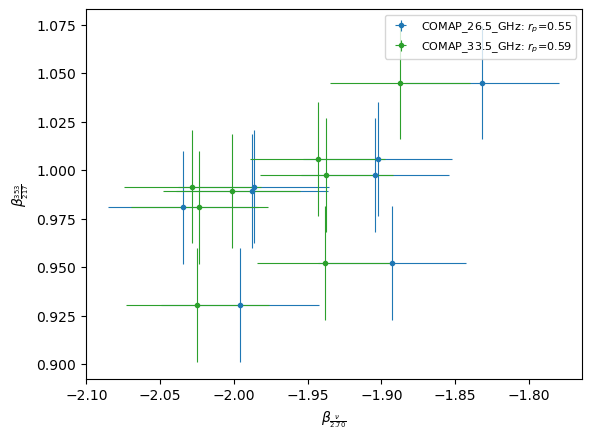

In [5]:
for i, Y_MAPY_PREFIX in enumerate(Y_MAPY_PREFIXES):
    Y_MAPX_PREFIX = Y_MAPX_PREFIXES[i]
    y_data_full = np.array([])
    yerr_data_full = np.array([])
    x_data_full = np.array([])
    xerr_data_full = np.array([])
    for j, L_BOUNDS in enumerate(L_BOUNDS_FULL):
        B_BOUNDS = B_BOUNDS_FULL[j]
        
        y_filename = f'TT_Plots_for_{LREGSIZE}x{BREGSIZE}_degree_rectangles_-_{Y_MAPY_PREFIX}_vs_{X_MAPY_PREFIX}_over_range_{L_BOUNDS[0]}_{B_BOUNDS[0]}_to_{L_BOUNDS[1]}_{B_BOUNDS[1]}.png_{FACTOR_COMPARING}_numresults.csv'
        x_filename = f'TT_Plots_for_{LREGSIZE}x{BREGSIZE}_degree_rectangles_-_{Y_MAPX_PREFIX}_vs_{X_MAPX_PREFIX}_over_range_{L_BOUNDS[0]}_{B_BOUNDS[0]}_to_{L_BOUNDS[1]}_{B_BOUNDS[1]}.png_{FACTOR_COMPARING}_numresults.csv'
        yerr_filename = f'TT_Plots_for_{LREGSIZE}x{BREGSIZE}_degree_rectangles_-_{Y_MAPY_PREFIX}_vs_{X_MAPY_PREFIX}_over_range_{L_BOUNDS[0]}_{B_BOUNDS[0]}_to_{L_BOUNDS[1]}_{B_BOUNDS[1]}.png_{FACTOR_COMPARING}err_numresults.csv'
        xerr_filename = f'TT_Plots_for_{LREGSIZE}x{BREGSIZE}_degree_rectangles_-_{Y_MAPX_PREFIX}_vs_{X_MAPX_PREFIX}_over_range_{L_BOUNDS[0]}_{B_BOUNDS[0]}_to_{L_BOUNDS[1]}_{B_BOUNDS[1]}.png_{FACTOR_COMPARING}err_numresults.csv'
    
        y_data = np.genfromtxt(f'{CSV_RESDIR}/{y_filename}', delimiter=',', dtype=float)
        x_data = np.genfromtxt(f'{CSV_RESDIR}/{x_filename}', delimiter=',', dtype=float)
        yerr_data = np.genfromtxt(f'{CSV_RESDIR}/{yerr_filename}', delimiter=',', dtype=float)
        xerr_data = np.genfromtxt(f'{CSV_RESDIR}/{xerr_filename}', delimiter=',', dtype=float)

        y_data_full = np.append(y_data_full, y_data)
        x_data_full = np.append(x_data_full, x_data)
        yerr_data_full = np.append(yerr_data_full, yerr_data)
        xerr_data_full = np.append(xerr_data_full, xerr_data)

    corr_coef, pvalue = pearsonr(x_data_full, y_data_full)
    pcorr_label = r'$r_{p}$'
    plt.errorbar(x_data_full, y_data_full, yerr_data_full, xerr_data_full, fmt='.', linewidth=0, elinewidth=0.8, label=f'{Y_MAPX_PREFIX}: {pcorr_label}={corr_coef:.2f}')
    plt.plot(x_data_full, y_data_full, linewidth=0)
    
plt.xlabel(r"$\beta_{\frac{\nu}{2.70}}$")
plt.ylabel(r"$\beta_{\frac{353}{217}}$")
plt.legend(fontsize=8)
plt.show()

In [12]:
# /scratch/nas_comap1/jgalla/MPHYS_PROJECT/results_files/longitude_intercept_fits/TT_Plots_for_2.0x2.82_degree_rectangles_-_COMAP_33.5_GHz_vs_PLANCK_HFI_353_GHZ_(5')_over_range_16.26_-1.41_to_32.26_1.41.png_beta_numresults.csv
# /scratch/nas_comap1/jgalla/MPHYS_PROJECT/results_files/longitude_intercept_fits/TT_plots_for_2.0x2.82_degree_rectangles_-_COMAP_33.5_GHz_vs_PLANCK_HFI_353_GHZ_(5')_over_range_16.26_-1.41_to_32.26_1.41.png_beta_numresults.csv